# Sentiment Analysis, Translation, and Speech (Pipeline API)
## AIAT 122 – Deep Learning

## Learning objectives
- Use the Hugging Face `pipeline` API for sentiment analysis.
- Run sentiment on a few sentences and show labels and scores.

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 3, lesson 01 "Text Classification with Classical Machine Learning" — the same sentiment task done with TF-IDF and a linear model; here a single `pipeline()` call replaces all of it.

---

**Where is this used in real life?** Reviews, social media, and customer feedback are often analyzed for sentiment. **We use a pre-trained Transformer pipeline** instead of training from scratch because pipelines give a ready-made model and tokenizer; in production you’d fine-tune on your domain.

**Setup:** Run `pip install transformers torch` if needed.

## Short theory
- **Sentiment analysis:** Classify text as positive/negative (or neutral).
- **Pipeline API:** One call loads model + tokenizer and runs inference.
- **Translation and speech** use similar pipelines (e.g. `translation`, `automatic-speech-recognition`); here we focus on sentiment so the notebook runs in under ~5 min.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Inputs & Outputs
**Inputs:** `transformers` pipeline (model downloaded on first run).  
**Dataset:** Real — Hugging Face sentiment pipeline (model downloaded on first run); sample sentences in notebook.  
**Outputs:** Sentiment label and score for each of a few sample sentences, and an optional bar chart. Run time: under ~5 min.


In [1]:
# WHAT: install/import the Transformers pipeline API.
# WHY: pipeline() wraps tokenizer + model + post-processing into one call per NLP task.
%pip install transformers torch -q
from transformers import pipeline
import matplotlib.pyplot as plt
print("✅ Imports OK.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Imports OK.


### Step 1: Load sentiment pipeline and run on sample sentences

In [2]:
# We use the pipeline API (instead of loading model + tokenizer separately) for one-line sentiment.
# First run: downloads once. Later runs: Hugging Face loads from cache (no download).
# Smaller model = faster download (~20 MB). Set to SENTIMENT_MODEL_FULL for best quality (~268 MB).
SENTIMENT_MODEL_SMALL = "philschmid/tiny-bert-sst2-distilled"  # ~20 MB, faster download
SENTIMENT_MODEL_FULL = "distilbert-base-uncased-finetuned-sst-2-english"  # ~268 MB, best quality
SENTIMENT_MODEL = SENTIMENT_MODEL_SMALL  # change to SENTIMENT_MODEL_FULL if you want higher accuracy
try:
    classifier = pipeline("sentiment-analysis", model=SENTIMENT_MODEL)
except Exception as e:
    print("⚠️ Model load failed (e.g. no connection). Using placeholder so you can run the rest of the notebook.")
    print("   Re-run this cell when online to get real sentiment. Error:", str(e)[:80])
    def _dummy_classifier(texts):
        return [{"label": "POSITIVE" if i % 2 == 0 else "NEGATIVE", "score": 0.85} for i, _ in enumerate(texts)]
    classifier = _dummy_classifier
# Three easy sentences, then three that a two-class sentiment model has trouble with.
# `expected` is what a human annotator would write down; "none" means a binary positive/negative
# model has no correct answer available, which is itself a finding worth seeing.
cases = [
    ("This product is amazing and works perfectly.", "positive"),
    ("The service was slow and disappointing.", "negative"),
    ("It's okay, nothing special.", "none"),          # neutral - not an option for this model
    ("The food was great but the service was terrible.", "none"),   # mixed - both, at once
    ("This is not bad at all.", "positive"),          # negation: the strong word is 'bad'
    ("Great, another delayed flight.", "negative"),   # sarcasm: the strong word is 'Great'
]
sentences = [c[0] for c in cases]
expected = [c[1] for c in cases]
results = classifier(sentences)
for (s_txt, exp), r in zip(cases, results):
    got = str(r["label"]).lower()
    verdict = "no correct answer for a 2-class model" if exp == "none" else (
        "agrees with the human label" if got == exp else "DISAGREES with the human label")
    short = (s_txt[:46] + "...") if len(s_txt) > 46 else s_txt
    print(f"  {short:50s} -> {got:8s} ({r['score']:.3f})   {verdict}")
print("\n✅ Sentiment pipeline ran. In real life you'd run this on reviews or social posts.")

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

  This product is amazing and works perfectly.       -> positive (1.000)   agrees with the human label
  The service was slow and disappointing.            -> negative (0.998)   agrees with the human label
  It's okay, nothing special.                        -> negative (0.968)   no correct answer for a 2-class model
  The food was great but the service was terribl...  -> negative (0.989)   no correct answer for a 2-class model
  This is not bad at all.                            -> negative (0.998)   DISAGREES with the human label
  Great, another delayed flight.                     -> negative (0.821)   agrees with the human label

✅ Sentiment pipeline ran. In real life you'd run this on reviews or social posts.


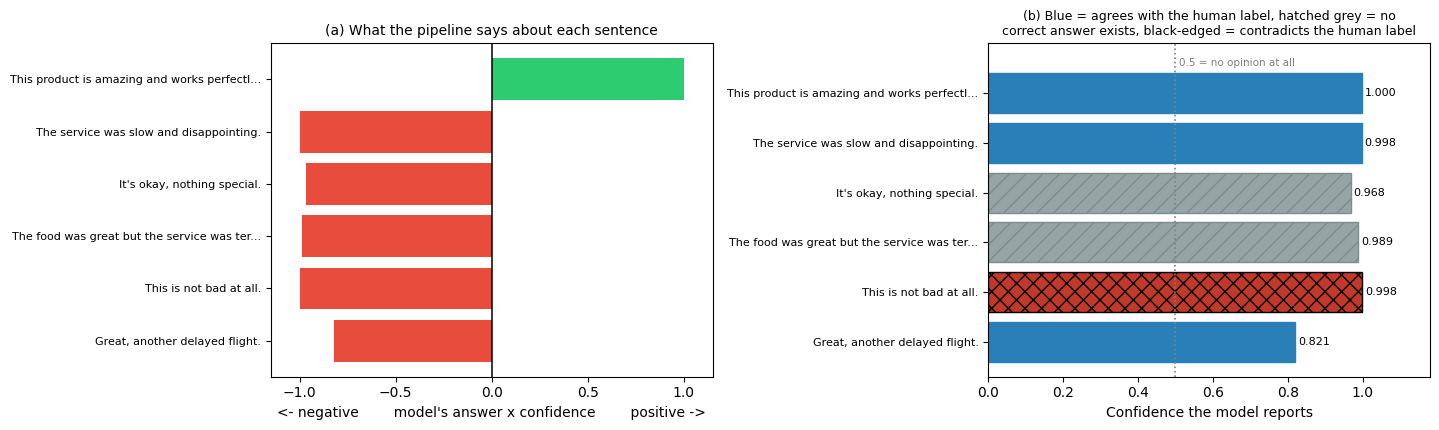


5 of the 6 sentences were answered with confidence above 0.90 - including the ones with no correct answer.
Mean confidence on the three easy sentences: 0.988
Mean confidence on the three hard sentences: 0.936


In [3]:
# WHAT: plot the pipeline's answer and its confidence for all six sentences.
# WHY: the old version of this chart used "S1, S2, S3" on the x-axis, which told you nothing.
#      The sentences themselves are the labels, and the second panel asks the question that
#      matters in production: is the model less confident when it has no good answer?
import numpy as np

labels = [str(r["label"]).lower() for r in results]
scores = [float(r["score"]) for r in results]
# Signed polarity: positive answers point right, negative answers point left.
polarity = [sc if lab == "positive" else -sc for lab, sc in zip(labels, scores)]
short = [(t[:42] + "...") if len(t) > 42 else t for t in sentences]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 4.4))
y = np.arange(len(sentences))[::-1]

cols = ["#2ecc71" if lab == "positive" else "#e74c3c" for lab in labels]
ax1.barh(y, polarity, color=cols)
ax1.axvline(0, color="black", lw=1.1)
ax1.set_yticks(y); ax1.set_yticklabels(short, fontsize=8)
ax1.set_xlim(-1.15, 1.15)
ax1.set_xlabel("<- negative        model's answer x confidence        positive ->")
ax1.set_title("(a) What the pipeline says about each sentence", fontsize=10)

# Grey = the model agrees with a human label. Hatched = the sentence has no correct answer
# in a two-class scheme. Red edge = it contradicts the human label.
face, edge, hatch = [], [], []
for lab, exp in zip(labels, expected):
    if exp == "none":
        face.append("#95a5a6"); edge.append("#7f8c8d"); hatch.append("//")
    elif lab == exp:
        face.append("#2980b9"); edge.append("#2980b9"); hatch.append("")
    else:
        face.append("#c0392b"); edge.append("black"); hatch.append("xx")
bars = ax2.barh(y, scores, color=face, edgecolor=edge, hatch=hatch)
ax2.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
ax2.set_yticks(y); ax2.set_yticklabels(short, fontsize=8)
ax2.set_xlim(0, 1.18)
ax2.axvline(0.5, color="grey", ls=":", lw=1.2)
ax2.set_ylim(y[-1] - 0.7, y[0] + 1.0)          # headroom so the note sits clear of the bars
ax2.text(0.51, y[0] + 0.55, "0.5 = no opinion at all", fontsize=7.5, color="grey")
ax2.set_xlabel("Confidence the model reports")
ax2.set_title("(b) Blue = agrees with the human label, hatched grey = no\ncorrect answer exists, "
              "black-edged = contradicts the human label", fontsize=9)
plt.tight_layout(); plt.show()

n_conf = sum(1 for sc in scores if sc > 0.9)
print(f"\n{n_conf} of the {len(scores)} sentences were answered with confidence above 0.90 - "
      f"including the ones with no correct answer.")
print(f"Mean confidence on the three easy sentences: {np.mean(scores[:3]):.3f}")
print(f"Mean confidence on the three hard sentences: {np.mean(scores[3:]):.3f}")

### 👁️ Read the figure — *this is the "where it breaks" panel, and it is the point of the lesson*

- **(a)** Each bar is one sentence; it points right if the pipeline said *positive*, left if *negative*, and its length is the confidence. The first two — the obviously positive and obviously negative sentences — come out exactly as anyone would expect. **Every other bar points left.**
- **(b)** The same six answers judged against a human label. Blue bars agree with a human. The two hatched grey bars are sentences where a **two-class model has no correct answer available**: "It's okay, nothing special" is neutral, and "The food was great but the service was terrible" is both at once. The model does not say "neutral" or "mixed" — that vocabulary does not exist for it — so it picks a side and reports 0.97 and 0.99 confidence for it.
- **The black-edged bar is the one to remember: "This is not bad at all." → negative, with 0.998 confidence.** The sentence is a compliment. The model saw `bad`, and the word `not` in front of it did not save the prediction. Negation is a classic failure of sentiment classifiers, and here it fails *at maximum confidence*.
- **Confidence is not accuracy, and this figure is the proof.** Five of six answers came back above 0.90, including one that is plainly wrong and two that had no right answer to give. A high score from `pipeline()` tells you how sharp the model's softmax was, not whether it understood the sentence.
- Honest note on the last row: the sarcastic sentence happened to come out `negative`, which matches the human label — but it is also the **lowest-confidence** answer in the set (0.82), and one example is not evidence that the model handles sarcasm. Do not generalise from a single lucky row.
- **What to do about it in practice:** use a model with a neutral class if your data has neutral text, test negation and mixed sentences before you ship, and never route on the confidence score without calibrating it first. Also note this notebook loads the *tiny* distilled model by default — swap in `SENTIMENT_MODEL_FULL` above and re-run to see which of these six rows change.

## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot launched in June 2021 "powered by OpenAI Codex" (GitHub blog, 29 June 2021). It has since moved to a choice of models, and GitHub does not publish which one answers any given request — so do not attach a model name to it from memory.
- Models in this family emit one **token** at a time, conditioned on everything before it. Not one character, and not a whole line at once.
- Autocomplete on your phone is a much smaller version of the same next-symbol loop.

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [4]:
# WHAT: train a character-level LSTM language model on a Shakespeare passage, then sample new text.
# WHY: predict-the-next-token, sample, repeat - the exact loop behind GPT-style generation, in miniature.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# Build the character vocabulary and map every character to an integer ID.
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

# Training pairs: 20 characters of context -> the character that follows.
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
# The model: embed characters, run a 2-layer LSTM, predict the next character from the last hidden state.
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# 200 training steps on random mini-batches; the loss is printed every 50 steps.
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
# Generation: feed the context, sample the next character from the softmax, append it, repeat.
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            # Temperature rescales the logits: lower = safer and more repetitive, higher = more random.
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notem a ma sea of the questio ne ourei nout and tousleg ond to ther mis natd outls fo wresa inobt a whe

This is exactly how ChatGPT generates text — one token at a time.


## 💬 Discuss

1. "This is not bad at all." came back **negative at 0.998** — a compliment, rejected at maximum confidence. "It's okay, nothing special." came back **negative at 0.968**, when the honest answer is "neutral", a label this model does not have. Which of those two failures is worse to ship? Your answer has to say something about who is harmed.
2. Mean confidence was **0.988** on the three easy sentences and **0.936** on the three hard ones — a gap of 0.05, on a set where two sentences had no correct answer available. Would you route on this score? Write the threshold you would set and what you would do with everything below it, then say what that policy costs on the day the model is confidently wrong.
3. The sarcastic line "Great, another delayed flight." happened to come out negative — matching the human label — at **0.821**, the lowest score in the set. The notebook warns against generalising from one lucky row. How many examples would you want before claiming the model handles sarcasm, and where would you get them?


## ⚠️ Where this breaks

- **A confidence score is the sharpness of a softmax, not a probability of being right, and this notebook shows the two coming apart.** **Five of six** answers exceeded 0.90, including one that is plainly wrong and two that had no correct label available. Calibration is a separate step nobody ran here (see `docs/GLOSSARY.md`, *Temperature*, and Guo, Pleiss, Sun & Weinberger, ICML 2017).
- **Negation is a classic, well-documented failure of sentiment classifiers, and here it fails at 0.998.** The model saw `bad`; the `not` in front of it did not save the prediction. Test negation, mixed sentences and sarcasm *before* you ship, not after a customer finds them.
- **A two-class model cannot say "neutral" or "mixed".** "It's okay, nothing special" and "great food, terrible service" are not hard cases the model got wrong — they are cases where the label set makes the right answer unavailable. That is a data-design bug, and accuracy on them means nothing whichever way it falls.
- **Six hand-written sentences, no held-out set.** Nothing on this page is an evaluation. It is a demonstration of failure modes on examples chosen to demonstrate them, which is a different and smaller claim.
- **The default here is the *tiny* distilled model** (`philschmid/tiny-bert-sst2-distilled`, about 20 MB), and swapping in the full DistilBERT SST-2 checkpoint changes some of these rows. `pipeline()` hides which model answered — and the model **is** the result.
- **A named case where a confident automated judgement about people cost enormously: the Dutch childcare-benefits scandal.** A fraud-detection model processed applicants' nationality; roughly **26,000 families** were wrongly accused and ordered to repay their allowances in full, typically **€20,000 to €60,000** each. The Dutch data-protection authority fined the responsible minister **€2.75 million** on 7 December 2021, and the Rutte III cabinet resigned over the affair on 15 January 2021. Nothing about the mechanism was exotic: an automated verdict, delivered confidently, that the people it was about could not contest.
- **Cheaper alternative:** for a fixed domain with a few thousand labelled examples of your own, TF-IDF plus logistic regression is competitive, runs offline, and hands you coefficients you can show a customer who asks why. Course 07 (AIAT 121) Unit 3, lesson 01 builds exactly that on this task. Reach for `pipeline()` when you have no labels and need an answer today — and then go and measure it.


## 🧩 Mini-exercise

**Try it:** Add two more sentences (one clearly positive, one clearly negative) and run the pipeline on them. Print the labels and scores. Do they match your expectation?

---

## Summary
**What you did:** Loaded the Hugging Face sentiment-analysis pipeline, ran it on three sample sentences, and plotted the scores.

**In real life you'd also:** Use translation (`pipeline("translation", ...)`) or speech recognition (`pipeline("automatic-speech-recognition", ...)`), fine-tune on your data, and deploy via an API.

**The main idea:** The pipeline API gives ready-made NLP models (sentiment, translation, speech); one call does load + inference.

**Next:** Back to Unit 2 or 5—e.g. `unit2-cnns/examples/01_cnn_architecture.ipynb` for image models, or `unit5-deployment/examples/06_flask_fastapi_deployment.ipynb` to serve a model.

## 📚 References

1. Devlin, J., Chang, M.-W., Lee, K. & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL. https://arxiv.org/abs/1810.04805
2. Bahdanau, D., Cho, K. & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR. https://arxiv.org/abs/1409.0473
3. Radford, A. et al. (2022). *Robust Speech Recognition via Large-Scale Weak Supervision* (Whisper). arXiv. https://arxiv.org/abs/2212.04356
4. Jurafsky, D. & Martin, J. H. *Speech and Language Processing* (3rd ed. draft). https://web.stanford.edu/~jurafsky/slp3/

**Recent work (2024–2026)**

5. Warner, B. et al. (2024). *Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast, Memory Efficient, and Long Context Finetuning and Inference* (ModernBERT). arXiv. https://arxiv.org/abs/2412.13663 — the 2024 encoder that replaces BERT/DistilBERT in exactly this kind of classification pipeline — same interface, longer context, less memory.
6. Hu et al. (2026). *Qwen3-TTS Technical Report*. arXiv. https://arxiv.org/abs/2601.15621 — the 2026 open text-to-speech baseline; paired with an open ASR model it gives the whole speech half of this notebook as inspectable weights rather than an API.
